# 영상인공지능처리 기말 프로젝트
## 동전 개수 세기

수업에서 배운 영상처리 기법을 활용하여 **동전 개수 세기 프로그램**을 직접 구현합니다.

---

### 📋 제출물
- Python 소스코드 (`.ipynb`)
- 발표 자료 (PPT 또는 PDF, 5~10분 분량)
- 결과 이미지 캡처 — 단계별 시각화 화면

---

### 📊 채점 기준
| 등급 | 조건 |
|------|------|
| **A** | 동전을 정확히 인식해 개수 세기 |
| **B** | 동전을 인식해 개수 세기 |
| **C** | 원을 인식해 개수 세기 |

---

## 🔍 문제 인식 및 정의

### 문제 인식 (어떤 문제를 해결할 것인가?)

> "동전이 여러 개 놓여있을 때, 사람이 직접 세지 않아도 컴퓨터가 자동으로 개수를 세줄 수 있을까?"

- 동전이 많으면 사람이 세다가 실수할 수 있음
- 매번 손으로 세는 것은 시간이 걸림
- 카메라로 찍은 사진 한 장으로 자동으로 셀 수 있다면 편리함

### 문제 정의 (무엇을 만들 것인가?)

| 항목 | 내용 |
|------|------|
| 입력 | 동전 사진 1장 |
| 출력 | 동전 개수 숫자 + 각 동전에 번호가 표시된 이미지 |
| 조건 | 동전끼리 겹치지 않음 |

---

## 🗺️ 전체 처리 흐름

```
📷 입력 이미지 (컬러 사진)
  ↓ [1단계] 그레이스케일 변환  → 색상 정보 제거, 흑백으로 변환
  ↓ [2단계] 가우시안 필터      → 노이즈 제거, 이미지를 부드럽게
  ↓ [3단계] 이진화 (Otsu)     → 동전 영역(흰색)과 배경(검은색)으로 분리
  ↓ [4단계] 모폴로지 연산      → 잡티 제거, 동전 영역 깔끔하게 정리
  ↓ [5단계] 외곽선 검출        → 동전 하나하나의 테두리 찾기
  ↓ [6단계] 원형성 계산 + 판별 → 원에 가까운 것만 동전으로 인정
  ↓ [7단계] 결과 출력          → 동전 개수 + 번호 표시 이미지
```

---

## 📚 수업에서 배운 함수 활용

| 처리 단계 | 사용 기법 | 수업 챕터 |
|---------|---------|----------|
| 그레이스케일 변환 | `cv2.cvtColor()` | 기초 |
| 가우시안 필터 | `cv2.GaussianBlur()` | 04 영역처리 |
| 이진화 | `cv2.threshold()` + Otsu | 03 이진화 |
| 모폴로지 연산 | `cv2.morphologyEx()` | 06~07 이진 영상 처리 |
| 외곽선 검출 | `cv2.findContours()` | 종합 |
| 원형성 계산 | 수식 계산 | 종합 |

---

## 1단계. 라이브러리 불러오기

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

---

## 2단계. 이미지 불러오기

흰 배경 위에 동전이 놓인 사진을 불러옵니다.  
흰 배경은 이진화 시 동전(어두운 영역)과 배경(밝은 영역)의 대비가 커서 정확한 검출이 가능합니다.

### `cv2.imread(path)` — 이미지 불러오기

| 파라미터 | 설명 |
|---------|------|
| `path` | 불러올 이미지 파일 경로 |
| 반환값 | BGR 형식의 numpy 배열 |

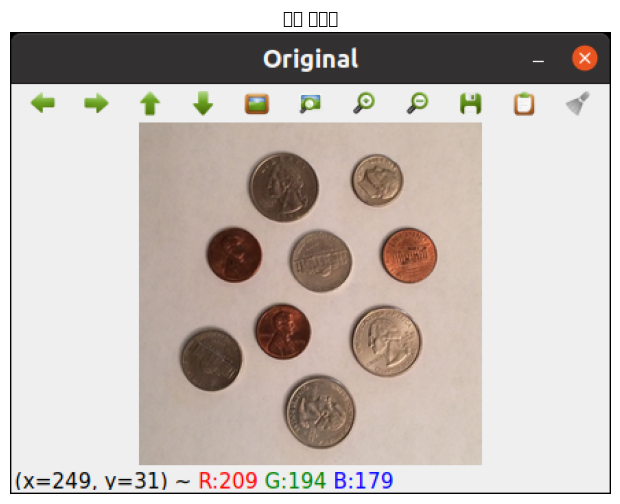

이미지 크기: (337, 438, 3)


In [11]:
# 샘플 동전 이미지 다운로드 (흰 배경, 동전 7개)
url = "https://shrishailsgajbhar.github.io/assets/images/20210202/pic1.png"
urllib.request.urlretrieve(url, "coins.png")

# 이미지 불러오기
img_bgr = cv2.imread("coins.png")

# BGR → RGB 변환 후 출력 (matplotlib은 RGB 순서 사용)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("원본 이미지")
plt.axis("off")
plt.show()

print("이미지 크기:", img_bgr.shape)

---

## 3단계. 그레이스케일 변환 (컬러 → 흑백)

컬러 이미지(BGR)를 흑백 이미지(그레이스케일)로 변환합니다.  
동전을 찾을 때 색상 정보는 필요 없으므로 흑백으로 변환하면 계산이 빨라지고 이진화도 더 정확해집니다.

### `cv2.cvtColor(src, code)` — 색상 공간 변환

| 파라미터 | 설명 |
|---------|------|
| `src` | 변환할 원본 이미지 |
| `code` | `COLOR_BGR2GRAY`: 컬러→흑백, `COLOR_BGR2RGB`: BGR→RGB |

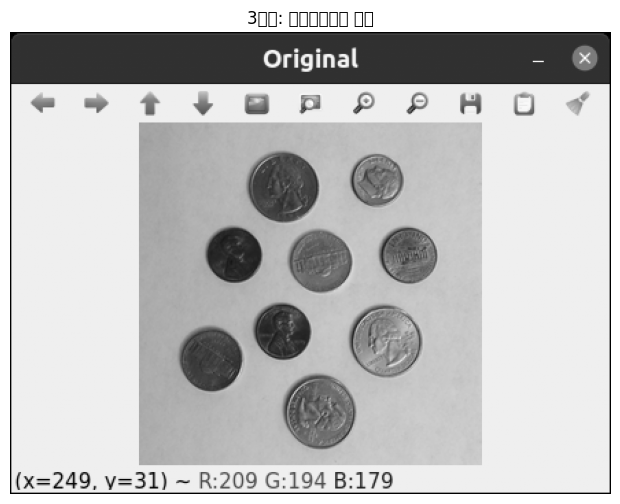

In [12]:
# 컬러(BGR) → 흑백(그레이스케일) 변환
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("3단계: 그레이스케일 변환")
plt.axis("off")
plt.show()

---

## 4단계. 가우시안 필터 (노이즈 제거)

이미지를 살짝 흐리게 만들어 노이즈(잡음)를 제거합니다.  
노이즈를 제거하지 않으면 이진화 시 잡티가 동전으로 잘못 검출될 수 있습니다.

### `cv2.GaussianBlur(src, ksize, sigmaX)` — 가우시안 블러

| 파라미터 | 설명 |
|---------|------|
| `src` | 입력 이미지 |
| `ksize` | 필터 크기 — **홀수**로 입력, 숫자가 클수록 더 흐려짐 |
| `sigmaX` | `0`으로 설정하면 ksize에 맞게 자동 계산 |

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local

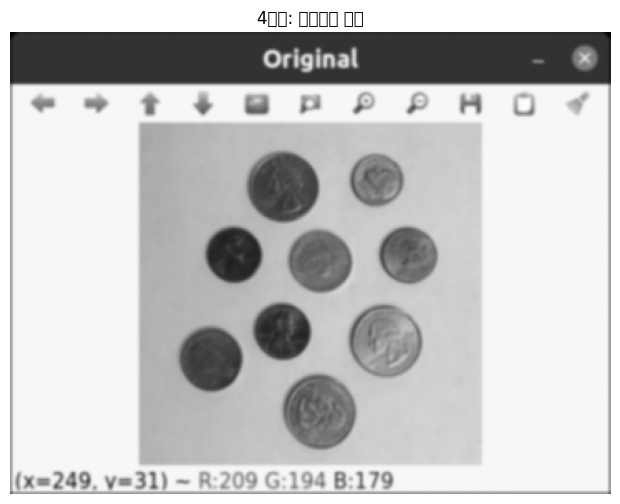

In [13]:
# 가우시안 필터로 노이즈 제거
blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(8, 6))
plt.imshow(blur, cmap="gray")
plt.title("4단계: 가우시안 필터")
plt.axis("off")
plt.show()

---

## 5단계. 이진화 — Otsu 방법

이미지를 흰색(255)과 검은색(0) 두 가지 값으로만 바꿉니다.  
동전 영역과 배경을 분리하는 핵심 단계입니다.

### `cv2.threshold(src, thresh, maxval, type)` — 이진화

| 파라미터 | 설명 |
|---------|------|
| `src` | 입력 이미지 (그레이스케일) |
| `thresh` | 임계값 — `THRESH_OTSU` 사용 시 `0`으로 설정하면 자동 계산 |
| `maxval` | 임계값을 넘는 픽셀에 적용할 값 — 보통 `255` |
| `type` | `THRESH_BINARY_INV`: 어두운 부분을 흰색으로, `THRESH_OTSU`: 자동 임계값 |

> `THRESH_BINARY_INV`를 사용하는 이유: 동전은 배경보다 어둡기 때문에 반전시켜야 동전 영역이 흰색이 됩니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


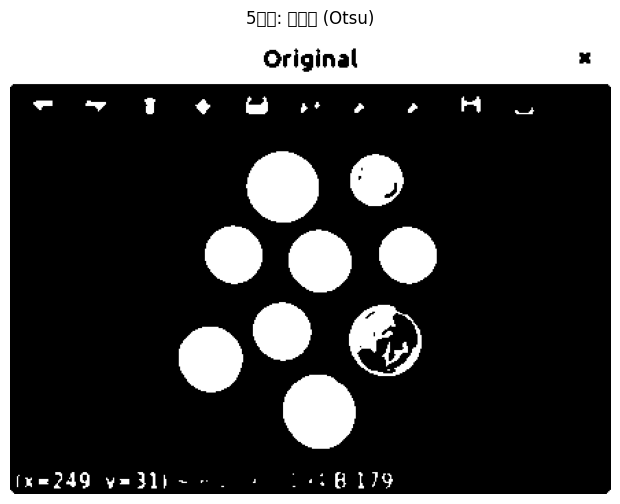

In [14]:
# Otsu 이진화 — 어두운 동전 영역을 흰색으로 변환
_, binary = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap="gray")
plt.title("5단계: 이진화 (Otsu)")
plt.axis("off")
plt.show()

---

## 6단계. 모폴로지 연산 (잡티 제거)

이진화 결과에서 작은 잡티를 제거하고 동전 영역을 깔끔하게 정리합니다.

### `np.ones(shape, dtype)` — 커널 생성

| 파라미터 | 설명 |
|---------|------|
| `shape` | 커널 크기 — `(5, 5)`는 5×5 사각형 |
| `dtype` | `np.uint8`: 0~255 정수값 |

### `cv2.morphologyEx(src, op, kernel, iterations)` — 모폴로지 연산

| 파라미터 | 설명 |
|---------|------|
| `src` | 입력 이진 이미지 |
| `op` | `MORPH_OPEN`: 열림(잡티 제거), `MORPH_CLOSE`: 닫힘(구멍 메우기) |
| `kernel` | 연산에 사용할 구조 요소 |
| `iterations` | 반복 횟수 — 숫자가 클수록 더 강하게 처리됨 |

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54260 (\N{HANGUL SYLLABLE POL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


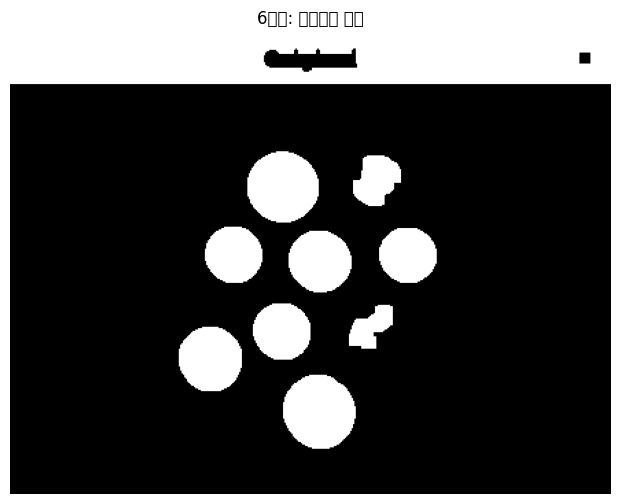

In [15]:
# 5x5 커널 생성
kernel = np.ones((5, 5), np.uint8)

# MORPH_OPEN: 작은 잡티 제거, 동전 영역 유지
morph = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# 결과 이미지 복사본 준비
result = img_bgr.copy()

plt.figure(figsize=(8, 6))
plt.imshow(morph, cmap="gray")
plt.title("6단계: 모폴로지 연산")
plt.axis("off")
plt.show()

---

## 7단계. 동전 개수 세기 (핵심 단계)

모폴로지 처리된 이미지에서 동전 영역을 찾아 개수를 셉니다.

**전체 흐름:**
1. 외곽선 찾기 — `cv2.findContours()`
2. 너무 작은 영역(노이즈) 제거 — `cv2.contourArea()`
3. 원형성 계산 — `cv2.arcLength()` + 수식
4. 동전 판별 — 원형성 0.7 이상
5. 외곽선 그리기 — `cv2.drawContours()`
6. 중심 좌표 계산 — `cv2.moments()`
7. 번호 표시 — `cv2.putText()`

---

### `cv2.findContours(image, mode, method)` — 외곽선 검출

| 파라미터 | 설명 |
|---------|------|
| `image` | 입력 이진 이미지 |
| `mode` | `RETR_EXTERNAL`: 가장 바깥쪽 외곽선만 검출 |
| `method` | `CHAIN_APPROX_SIMPLE`: 꼭짓점만 저장(메모리 절약) |

### 원형성 공식

$$\text{원형성} = \frac{4\pi \times \text{면적}}{\text{둘레}^2}$$

| 원형성 값 | 의미 |
|----------|------|
| **1.0** | 완벽한 원 |
| **0.7 ~ 0.9** | 동전처럼 거의 원 |
| **0.3 이하** | 울퉁불퉁한 모양 |

In [16]:
# 결과 이미지 및 카운터 초기화
result = img_bgr.copy()
circle_count = 0

# --------------------------------------------------
# 외곽선 찾기
# contours: 찾은 외곽선 목록 (동전 하나당 외곽선 하나)
# _       : 외곽선 계층 정보 (사용하지 않음)
# --------------------------------------------------
contours, _ = cv2.findContours(
    morph,
    cv2.RETR_EXTERNAL,       # 가장 바깥쪽 외곽선만 검출
    cv2.CHAIN_APPROX_SIMPLE  # 꼭짓점만 저장 (메모리 절약)
)

print("찾은 외곽선 수:", len(contours))

# --------------------------------------------------
# 외곽선을 하나씩 꺼내서 동전인지 확인
# --------------------------------------------------
for contour in contours:

    # 1) 너무 작은 영역(노이즈) 제거
    area = cv2.contourArea(contour)  # 면적 계산 (픽셀 단위)
    if area < 1000:
        continue  # 1000픽셀보다 작으면 잡티로 판단, 건너뜀

    # 2) 원형성 계산
    perimeter = cv2.arcLength(contour, True)  # 둘레 계산 (True = 닫힌 도형)
    if perimeter == 0:
        continue

    # 원형성 공식: 4π × 면적 / 둘레²
    # 완전한 원이면 1.0, 울퉁불퉁할수록 0에 가까워짐
    circularity = 4 * np.pi * area / (perimeter ** 2)

    # 3) 동전 판별 — 원형성 0.7 이상이면 동전으로 판단
    if circularity > 0.7:

        circle_count += 1  # 동전 개수 1 증가

        # 4) 외곽선을 초록색 선으로 표시
        cv2.drawContours(result, [contour], -1, (0, 255, 0), 3)

        # 5) 중심 좌표 계산 (모멘트 활용)
        M = cv2.moments(contour)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])  # x 중심 좌표
            cy = int(M["m01"] / M["m00"])  # y 중심 좌표

            # 6) 동전 중심에 번호 표시 (빨간색)
            cv2.putText(
                result,
                str(circle_count),
                (cx - 10, cy + 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 0, 255),
                2
            )

print("검출된 동전 개수:", circle_count)

찾은 외곽선 수: 10
검출된 동전 개수: 7


---

## 8단계. 최종 결과 출력

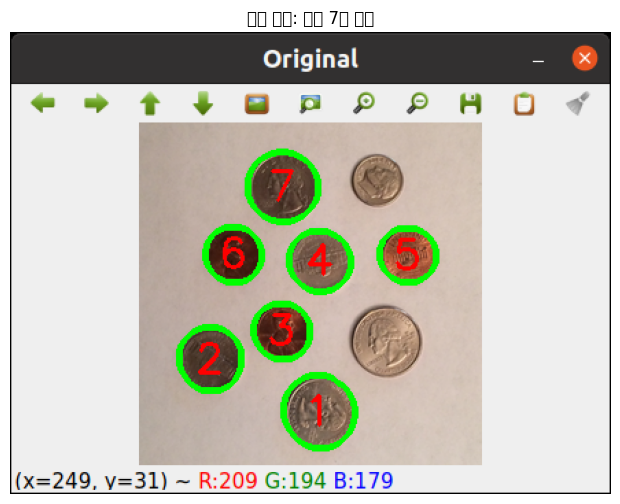


✅ 총 7개의 동전이 검출되었습니다.


In [17]:
# BGR → RGB 변환 후 출력
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(result_rgb)
plt.title(f"최종 결과: 동전 {circle_count}개 검출")
plt.axis("off")
plt.show()

print(f"\n✅ 총 {circle_count}개의 동전이 검출되었습니다.")

---

## 💡 생각해 봅시다

1. **왜 컬러 이미지를 바로 이진화하지 않고, 먼저 그레이스케일로 바꿀까요?**  
   → 이진화는 밝기 값 하나만 기준으로 합니다. 컬러(3채널)로 바로 이진화하면 R/G/B 중 어떤 채널 기준인지 정하기 어렵고 계산도 3배 느려집니다.

2. **가우시안 필터를 적용하지 않으면 어떤 문제가 생길까요?**  
   → 이미지의 미세한 노이즈까지 동전으로 잘못 인식해서 개수가 실제보다 훨씬 많이 나옵니다.

3. **모폴로지 연산에서 `MORPH_OPEN`을 쓰는 이유는 무엇일까요?**  
   → 작은 잡티는 없애고 동전처럼 큰 영역은 그대로 유지합니다. `MORPH_CLOSE`는 반대로 영역 안의 구멍을 메웁니다.

4. **원형성이 1에 가까울수록 원이라면, 동전의 원형성은 몇 정도일까요?**  
   → 이 이미지의 동전은 약 **0.90 ~ 0.91** 정도입니다. 흰 배경 위에서 촬영한 사진이라 원형성이 매우 높게 나옵니다.

---

## ⚠️ 자주 발생하는 문제

| 문제 | 원인 | 해결 방법 |
|------|------|----------|
| 동전 2개가 1개로 인식 | 동전이 붙어있음 | 간격을 더 벌려서 재촬영 |
| 개수가 너무 많이 나옴 | 노이즈가 동전으로 인식 | 모폴로지 커널 크기 키우기 |
| 동전이 아예 안 잡힘 | 이진화 방향 반대 | `THRESH_BINARY_INV` 확인 |
| 배경도 같이 잡힘 | 배경이 어두움 | 흰 종이 배경으로 재촬영 |